In [3]:
# ============================
# Week 03 BO (F5): Surrogate + Uncertainty + Acquisition + Next X
# ============================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# ----------------------------
# 0) CONFIG (F5)
# ----------------------------
INPUTS_PATH = "data/F5/initial_inputs.npy"
OUTPUTS_PATH = "data/F5/initial_outputs.npy"

BOUNDS = np.array([[0.0, 1.0]] * 4)   # F5 is 4D with [0,1] bounds
MAXIMIZE = True                       # F5 goal is MAXIMISE

BATCH_SIZE = 5                        # if tutor accepts a batch
N_CANDIDATES = 40000                  # random candidates for acquisition search
LOCAL_STD = 0.03                      # local refinement radius around best-known point
KAPPA = 0.5                           # UCB exploration weight (smaller = more exploit)



In [5]:
# ----------------------------
# 1) Load data
# ----------------------------
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (n,4), got {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Expected y shape (n,), got {y.shape}"

print("F5 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Best observed y:", float(y.max()), "at X:", X[y.argmax()])

F5 SHAPE - Inputs: (22, 4) Outputs: (22,)
Best observed y: 3240.0066354498244 at X: [0.236344 0.904546 0.999999 0.988293]


In [7]:
# ----------------------------
# 2) Transform outputs (stabilise huge spread) + fit GP surrogate
# ----------------------------
y_t = np.log1p(y)   # log(1+y) handles extreme range smoothly

kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(X.shape[1]),
                                     length_scale_bounds=(1e-2, 1e2), nu=2.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,          # small nugget
    normalize_y=True,
    n_restarts_optimizer=8,
    random_state=0
)

gp.fit(X, y_t)

print("Fitted GP kernel:", gp.kernel_)

Fitted GP kernel: 2.41**2 * Matern(length_scale=[2.11, 0.605, 1.36, 0.806], nu=2.5)


Train RMSE (log1p scale): 0.0000
Train R2   (log1p scale): 1.0000


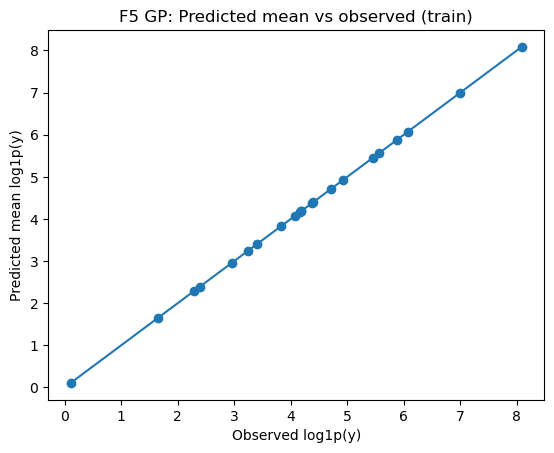

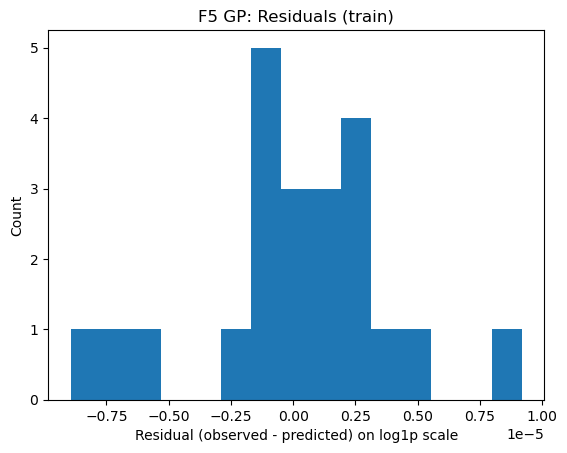

In [9]:
# ----------------------------
# 3) Diagnostics: predicted mean vs observed + residuals
# ----------------------------
mu_train, std_train = gp.predict(X, return_std=True)

mse = mean_squared_error(y_t, mu_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_t, mu_train)

print(f"Train RMSE (log1p scale): {rmse:.4f}")
print(f"Train R2   (log1p scale): {r2:.4f}")

plt.figure()
plt.scatter(y_t, mu_train)
mn, mx = float(min(y_t.min(), mu_train.min())), float(max(y_t.max(), mu_train.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed log1p(y)")
plt.ylabel("Predicted mean log1p(y)")
plt.title("F5 GP: Predicted mean vs observed (train)")
plt.show()

plt.figure()
plt.hist((y_t - mu_train), bins=15)
plt.xlabel("Residual (observed - predicted) on log1p scale")
plt.ylabel("Count")
plt.title("F5 GP: Residuals (train)")
plt.show()


In [10]:
# ----------------------------
# 4) Acquisition: Local UCB around best + small global sprinkle
#     (F5 looks unimodal with a sharp peak; focus near the summit.)
# ----------------------------
rng = np.random.default_rng(0)

best_idx = int(np.argmax(y_t))
x_best = X[best_idx].copy()

# local candidates around best
n_local = int(N_CANDIDATES * 0.8)
cand_local = x_best + rng.normal(0.0, LOCAL_STD, size=(n_local, X.shape[1]))
cand_local = np.clip(cand_local, BOUNDS[:, 0], BOUNDS[:, 1])

# global candidates to avoid getting stuck
n_global = N_CANDIDATES - n_local
cand_global = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(n_global, X.shape[1]))

candidates = np.vstack([cand_local, cand_global])

# optional: keep search in high-yield regime suggested by data (x2,x3,x4 high-ish)
mask = (
    (candidates[:, 1] >= 0.60) &
    (candidates[:, 2] >= 0.70) &
    (candidates[:, 3] >= 0.70) &
    (candidates[:, 0] <= 0.50)
)
candidates = candidates[mask]

mu_c, std_c = gp.predict(candidates, return_std=True)
ucb = mu_c + KAPPA * std_c  # maximise

# greedily pick a diverse batch (avoid near-duplicates)
order = np.argsort(-ucb)
selected = []
min_dist = 0.03  # separation in [0,1]^4

for idx in order:
    x = candidates[idx]
    if len(selected) == 0:
        selected.append(x)
        if len(selected) >= BATCH_SIZE:
            break
        continue
    d = np.linalg.norm(np.array(selected) - x, axis=1)
    if np.all(d >= min_dist):
        selected.append(x)
        if len(selected) >= BATCH_SIZE:
            break

X_next_batch = np.array(selected)

In [11]:
# ----------------------------
# 5) Print what to submit
# ----------------------------
np.set_printoptions(precision=6, suppress=True)

print("\nSuggested NEXT batch (submit if allowed):")
print(X_next_batch)

print("\nSingle best NEXT point (submit this if you can only submit ONE row):")
print(X_next_batch[0])

# Context only (NOT for submission)
pred_log, pred_std = gp.predict(X_next_batch[:1], return_std=True)
pred_y = np.expm1(pred_log)  # inverse log1p
print("\nModel context only (NOT for submission):")
print("Predicted mean y:", float(pred_y[0]), " | Predicted std (log-scale):", float(pred_std[0]))


Suggested NEXT batch (submit if allowed):
[[0.155843 0.7688   0.966134 0.998903]
 [0.150588 0.827942 1.       1.      ]
 [0.186083 0.809981 1.       1.      ]
 [0.240059 0.785023 1.       1.      ]
 [0.015346 0.720579 0.972671 0.968597]]

Single best NEXT point (submit this if you can only submit ONE row):
[0.155843 0.7688   0.966134 0.998903]

Model context only (NOT for submission):
Predicted mean y: 3200.2846956066323  | Predicted std (log-scale): 0.8010913873185589
